# US Housing Inventory Analysis:
## Trends, Regional Growth, and Market Stability


## Overview:
This project analyzes housing inventory data to evaluate long-term supply demands, compare regional housing dynamics, and identify patterns in market stability and seasonality.

The analysis focuses on understanding how housing inventory evolves over time and across regions to support data-driven rel estate and economic decision-making.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [230]:
data= pd.read_csv('data.csv')
metadata=pd.read_csv('metadata.csv')
merged=pd.merge(data,metadata,on='time_series_code',how='left')


C:\Users\USER\AppData\Local\Temp\ipykernel_27264\655687535.py:1: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  data= pd.read_csv('data.csv')


In [ ]:
housing=merged[merged['cat_desc']=='Housing Inventory Estimate'].copy()
housing.to_csv('housing/Housing Inventory.csv')

## EDA

In [ ]:
housing=pd.read_csv('housing/Housing Inventory.csv')
housing.drop('Unnamed: 0',axis=1,inplace=True)
housing.head()

,time_series_code,date,value,cat_code,cat_desc,category_level,dt_code,dt_desc,dt_unit,et_code,et_desc,et_unit,geo_code,geo_desc,is_adj,report,detail_code
0,ESTIMATE_TOTAL_US,2000-04-01,116047,ESTIMATE,Housing Inventory Estimate,0,TOTAL,Total Housing Units,Thousands of Units,NaN,NaN,NaN,US,United States,0,Housing Vacancies and Homeownership,TOTAL
1,ESTIMATE_OCC_US,2000-04-01,102274,ESTIMATE,Housing Inventory Estimate,0,OCC,Occupied Housing Units,Thousands of Units,NaN,NaN,NaN,US,United States,0,Housing Vacancies and Homeownership,OCC
2,ESTIMATE_OWNOCC_US,2000-04-01,68752,ESTIMATE,Housing Inventory Estimate,0,OWNOCC,Owner Occupied Housing Units,Thousands of Units,NaN,NaN,NaN,US,United States,0,Housing Vacancies and Homeownership,OWNOCC
3,ESTIMATE_RNTOCC_US,2000-04-01,33522,ESTIMATE,Housing Inventory Estimate,0,RNTOCC,Renter Occupied Housing Units,Thousands of Units,NaN,NaN,NaN,US,United States,0,Housing Vacancies and Homeownership,RNTOCC
4,ESTIMATE_VACANT_US,2000-04-01,13773,ESTIMATE,Housing Inventory Estimate,0,VACANT,Vacant Housing Units,Thousands of Units,NaN,NaN,NaN,US,United States,0,Housing Vacancies and Homeownership,VACANT


In [ ]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4830 entries, 0 to 4829
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   time_series_code  4830 non-null   object 
 1   date              4830 non-null   object 
 2   value             4830 non-null   int64  
 3   cat_code          4830 non-null   object 
 4   cat_desc          4830 non-null   object 
 5   category_level    4830 non-null   int64  
 6   dt_code           4830 non-null   object 
 7   dt_desc           4830 non-null   object 
 8   dt_unit           4830 non-null   object 
 9   et_code           0 non-null      float64
 10  et_desc           0 non-null      float64
 11  et_unit           0 non-null      float64
 12  geo_code          4830 non-null   object 
 13  geo_desc          4830 non-null   object 
 14  is_adj            4830 non-null   int64  
 15  report            4830 non-null   object 
 16  detail_code       4830 non-null   object 


In [ ]:
housing.isnull().sum()

time_series_code       0
date                   0
value                  0
cat_code               0
cat_desc               0
category_level         0
dt_code                0
dt_desc                0
dt_unit                0
et_code             4830
et_desc             4830
et_unit             4830
geo_code               0
geo_desc               0
is_adj                 0
report                 0
detail_code            0
dtype: int64

## Observation and Insight:
Missing values in columns (et_code, et_desc, et_unit) would be retained as NaN to preserve data intergrity

## Data Cleaning

In [ ]:

housing['date'].unique()

array(['2000-04-01', '2000-07-01', '2000-10-01', '2001-01-01',
       '2001-04-01', '2001-07-01', '2001-10-01', '2002-01-01',
       '2002-04-01', '2002-07-01', '2002-10-01', '2003-01-01',
       '2003-04-01', '2003-07-01', '2003-10-01', '2004-01-01',
       '2004-04-01', '2004-07-01', '2004-10-01', '2005-01-01',
       '2005-04-01', '2005-07-01', '2005-10-01', '2006-01-01',
       '2006-04-01', '2006-07-01', '2006-10-01', '2007-01-01',
       '2007-04-01', '2007-07-01', '2007-10-01', '2008-01-01',
       '2008-04-01', '2008-07-01', '2008-10-01', '2009-01-01',
       '2009-04-01', '2009-07-01', '2009-10-01', '2010-01-01',
       '2010-04-01', '2010-07-01', '2010-10-01', '2011-01-01',
       '2011-04-01', '2011-07-01', '2011-10-01', '2012-01-01',
       '2012-04-01', '2012-07-01', '2012-10-01', '2013-01-01',
       '2013-04-01', '2013-07-01', '2013-10-01', '2014-01-01',
       '2014-04-01', '2014-07-01', '2014-10-01', '2015-01-01',
       '2015-04-01', '2015-07-01', '2015-10-01', '2016-

In [ ]:
housing['date']=housing['date'].astype(str).str.strip()
housing['date']=pd.to_datetime(housing['date'],errors='coerce')
housing['month']=housing['date'].dt.month_name()

In [ ]:
housing['value']=housing['value'].astype(int)

In [232]:
housing['geo_desc'].unique()

array(['United States', 'South', 'Midwest', 'West', 'Northeast'],
      dtype=object)

In [ ]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4830 entries, 0 to 4829
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   time_series_code  4830 non-null   object        
 1   date              4830 non-null   datetime64[ns]
 2   value             4830 non-null   int64         
 3   cat_code          4830 non-null   object        
 4   cat_desc          4830 non-null   object        
 5   category_level    4830 non-null   int64         
 6   dt_code           4830 non-null   object        
 7   dt_desc           4830 non-null   object        
 8   dt_unit           4830 non-null   object        
 9   et_code           0 non-null      float64       
 10  et_desc           0 non-null      float64       
 11  et_unit           0 non-null      float64       
 12  geo_code          4830 non-null   object        
 13  geo_desc          4830 non-null   object        
 14  is_adj            4830 n

## Business Questions:
1. How has housing inventory changed over time?
2. Which region has the highest housing inventory?
3. Which regions are growing fastest in housing supply?
4. Which regions are most unstable?
5. Is there a pattern across months?


## 1. How has housing inventory changed over time?

Text(0.5, 0, '')

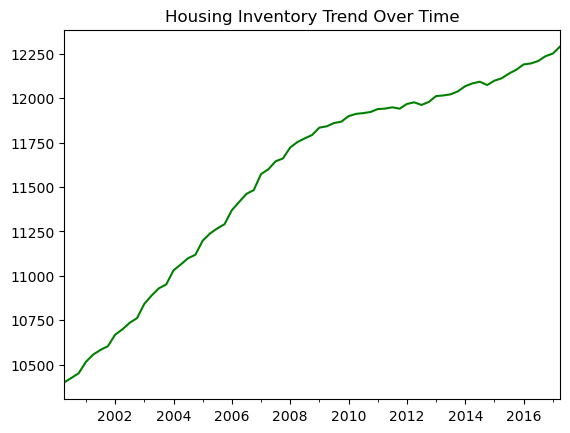

In [ ]:
trend= housing.groupby('date')['value'].mean()
trend.plot(color='green')
plt.title('Housing Inventory Trend Over Time')
plt.xlabel('')


### Insight:
This shows a steady upward trend from early 2000s and continuing consistently thereafter. This suggest increasing market capacity and development

## 2. Which region has the highest housing inventory?

Text(0, 0.5, '')

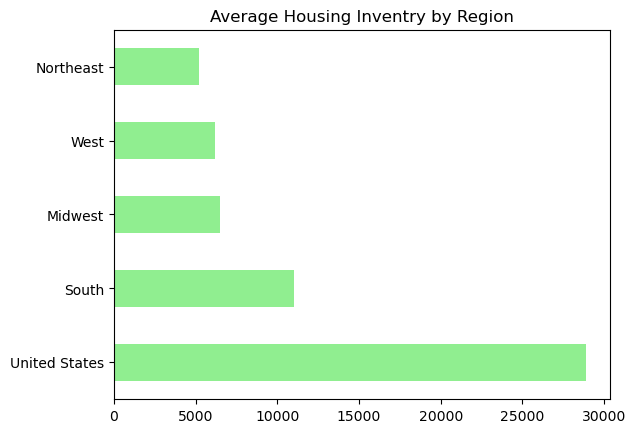

In [ ]:
region= housing.groupby('geo_desc')['value'].mean().sort_values(ascending=False)
region.plot.barh(color='lightgreen')
plt.title('Average Housing Inventry by Region')
plt.ylabel('')


### Insight:
United states aggregate records the highest housing inventory, this may affect population density, land availability, or slower development rates.

## 3. Which regions are growing fastest in housing supply?

Text(0, 0.5, '')

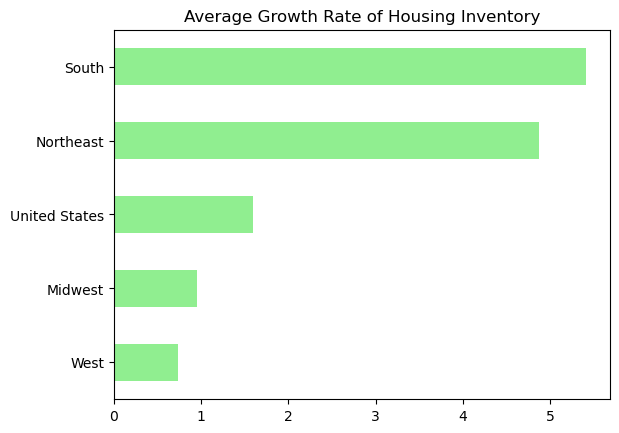

In [ ]:
housing=housing.sort_values('date')
housing['growth']=housing.groupby('geo_desc')['value'].pct_change()

growth= housing.groupby('geo_desc')['growth'].mean().sort_values()
growth.plot.barh(color='lightgreen')
plt.title('Average Growth Rate of Housing Inventory')
plt.ylabel('')

### Insight:
The south is experiencing rapid expansion in housing supply, likely driven by population growth and urban development, while slower growth in the west may indicate supply constraints.

## 4. Which regions are most unstable?

Text(0, 0.5, '')

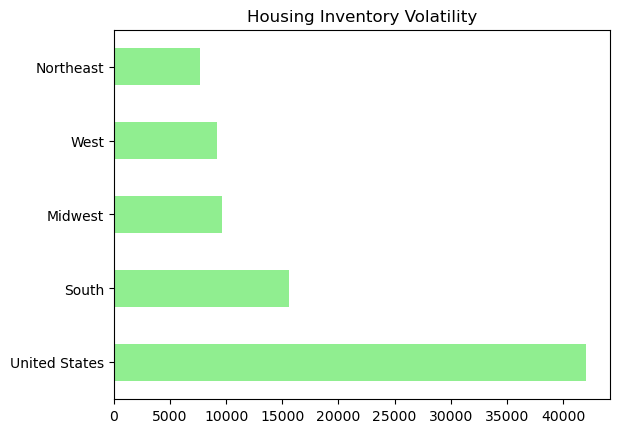

In [ ]:
volatility= housing.groupby('geo_desc')['value'].std().sort_values(ascending=False)
volatility.plot.barh(color='lightgreen')
plt.title('Housing Inventory Volatility')
plt.ylabel('')

### Insight:
Higher volatility in the US suggests fluctuations driven by multiple regional dynamics, whereas Northeast's stability indicates a more consistent and predictable housing supply.

## 5. Is there a pattern across months?

Text(0.5, 0, '')

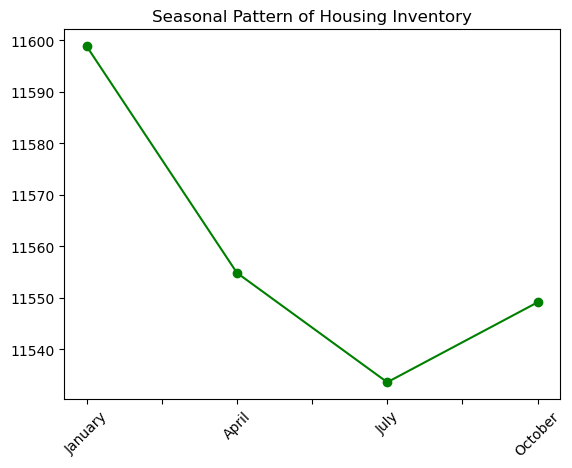

In [ ]:
season=housing.groupby('month')['value'].mean().reindex(['January','April',
                                            'July','October'])

season.plot.line(color='green',marker='o')
plt.xticks(rotation=45)
plt.title('Seasonal Pattern of Housing Inventory')
plt.xlabel('')

### Insight:
Housing inventory follows a quarterly pattern which suggests seasonal fluctuations in housing availability, possibly influenced by construction cycles, market demand, or reporting periods.


## Business Recommendations

1. Focus Investment in High-Growth Regions
* Prioritize real estate development and investment in the South, where housing supply is expanding rapidly and demand is likely increasing.


2. Develop targeted housing policies or incentives in the Northeast to address lower inventory levels and potential housing shortages.

3. Monitor and Manage Market Volatility
* Implement data-driven planning at the national level to stabilize fluctuations in housing supply and reduce uncertainty in the market.

4. Leverage Seasonal Trends for Strategic Planning

5. Investigate Constraints in Low-Growth Regions

## Conclusion

The analysis reveals consistent growth in housing inventory over time, with significant regional differences in supply levels, growth rates, and stability. These findings highlight the importance of region-specific strategies and seasonal planning in managing housing markets effectively.

